# 🌊 BinWaves Reconstruction

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
> - `Kp_coefficients.nc` file obtained with the `Propagation Notebook`.
> 
>
> **Outputs:**
> 
> 

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details open>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** or **WHACS** datasets).

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import xarray as xr
import numpy as np

# Smooth the spectrum with a centered rolling mean, keeping the original
# freq/dir resolution (unlike coarsen, which reduces the grid)

whacs_spectra = xr.open_dataset(
    "../../../../toolkit/data/outputs/offshore_spectra_44.679_-124.535_20200101_20201231.nc"
)
whacs_spectra["efth"] = (
    whacs_spectra["efth"]
    .rolling(freq=5, center=True, min_periods=1)
    .mean()
)
whacs_spectra['efth'] = whacs_spectra['efth']*np.pi/180            
whacs_spectra = whacs_spectra.coarsen(freq=3, dir=3, boundary="pad").mean()


In [3]:
# Load all the gridded kps and reproject

kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

# Use reindex (not interp) for direction: direction is circular, and the
# case bins (e.g. 352.5 deg) can fall outside the raw data's dir range
# (e.g. 5-350 deg), which makes interp produce NaN for that bin instead of
# wrapping around to the nearest neighbor.
whacs_spectra = whacs_spectra.reindex(freq=kp_coeffs.freq, dir=kp_coeffs.dir, method="nearest")

In [4]:
import pandas as pd
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("NEWPORT_CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra

offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    CAWCR_spectrum=whacs_spectra,
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
    fixed_direction=True,  # True if efth is already in degrees(no radians) and cawcr direction for wavespectra  already corrected (from -> to)'
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 180, time: 8621)> Size: 12MB
array([[1.55351655e-05, 4.15834281e-05, 4.06831817e-05, ...,
        5.99491895e-06, 1.34506678e-05, 2.27649384e-05],
       [2.20340421e-05, 6.23967010e-05, 6.93096475e-05, ...,
        1.15979057e-04, 9.07600973e-05, 1.56062615e-04],
       [9.59579243e-06, 3.85655738e-05, 4.90895637e-05, ...,
        3.07782903e-04, 1.98982157e-04, 2.24208119e-04],
       ...,
       [9.86506068e-07, 9.47420511e-07, 8.86618789e-07, ...,
        1.98888230e-06, 3.22910639e-06, 1.77291947e-06],
       [5.57473915e-07, 9.78711689e-07, 3.72370844e-07, ...,
        1.43577548e-06, 2.79635032e-06, 9.82385709e-07],
       [2.34314843e-07, 3.27849660e-07, 8.00166733e-08, ...,
        7.42417968e-07, 1.18328051e-06, 6.33102610e-07]],
      shape=(180, 8621))
Coordinates:
  * case_num   (case_num) int64 1kB 0 1 2 3 4 5 6 ... 174 175 176 177 178 179
  * time       (time) datetime64[ns] 69kB 2020-01-01T00:40:00 ... 2020-12-31T...
    latitude   float64 8B 44.68
    longitude  float64 8B 235.5

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

time_to_reconstruct = "2020-02-20"

# Reconstruct spectra
# NOTE: num_workers=1 avoids splitting the (already modest, one day) computation
# across several Dask workers, each capped at a small memory slice of this
# machine's limited free RAM fraction handles this comfortably.
reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs,
    num_workers=1,
    memory_limit=0.9,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 6MB
Dimensions:    (site: 45, freq: 29, dir: 24, time: 24)
Coordinates:
  * site       (site) int64 360B 1 2 3 4 5 6 7 8 9 ... 38 39 40 41 42 43 44 45
  * freq       (freq) float64 232B 0.03 0.033 0.0363 ... 0.3517 0.3866 0.425
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
  * time       (time) datetime64[ns] 192B 2020-02-20T00:40:00 ... 2020-02-20T...
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    coord_x    (site) float64 360B -124.8 -124.7 -124.5 ... -124.4 -124.2 -124.1
    coord_y    (site) float64 360B 44.0 44.0 44.0 44.0 ... 45.0 45.0 45.0 45.0
    latitude   float64 8B 44.68
    longitude  float64 8B 235.5
Data variables:
    kps        (time, site, freq, dir) float64 6MB 4.186e-08 ... 3.38e-07

(<Figure size 2000x1000 with 4 Axes>,
 <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

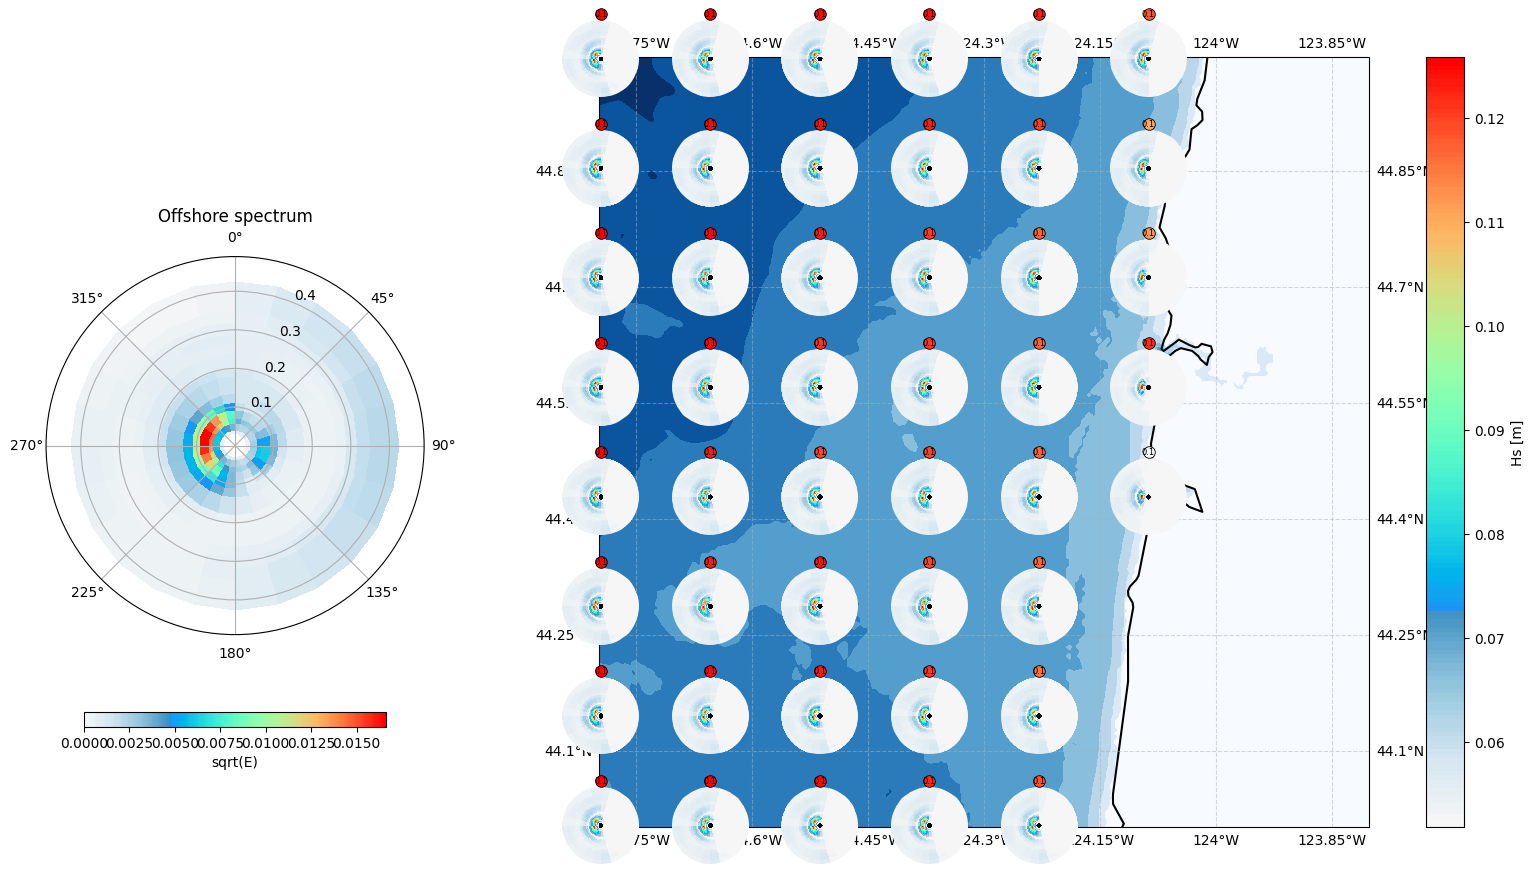

In [6]:
from utils.plotting import plot_spectrum_in_coastline
import numpy as np

time_to_plot = "2020-02-20 10:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("../../../../toolkit/data/outputs/GEBCO_-124.8_-123.8_44_45.nc").elevation.T

reconstructed_onshore_spectra_sites = reconstructed_onshore_spectra.rename({"kps": "kp"})

plot_spectrum_in_coastline(
    bathy=bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra_sites,
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    sites_for_spectrum=list(np.arange(0, reconstructed_onshore_spectra_sites.sizes["site"],1)),
)

## Reconstruct a time slice

In [7]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

time_slice_to_reconstruct = ["2020-02-20", "2020-02-25"]

# Reconstruct spectra
reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=slice(*time_slice_to_reconstruct)),
    kp_coeffs=kp_coeffs,
    num_workers=1,
    memory_limit=0.9,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 36MB
Dimensions:    (site: 45, freq: 29, dir: 24, time: 144)
Coordinates:
  * site       (site) int64 360B 1 2 3 4 5 6 7 8 9 ... 38 39 40 41 42 43 44 45
  * freq       (freq) float64 232B 0.03 0.033 0.0363 ... 0.3517 0.3866 0.425
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
  * time       (time) datetime64[ns] 1kB 2020-02-20T00:40:00 ... 2020-02-25T2...
    lat        float64 8B 0.0
    lon        float64 8B 0.0
    coord_x    (site) float64 360B -124.8 -124.7 -124.5 ... -124.4 -124.2 -124.1
    coord_y    (site) float64 360B 44.0 44.0 44.0 44.0 ... 45.0 45.0 45.0 45.0
    latitude   float64 8B 44.68
    longitude  float64 8B 235.5
Data variables:
    kps        (time, site, freq, dir) float64 36MB 4.186e-08 ... 1.001e-06

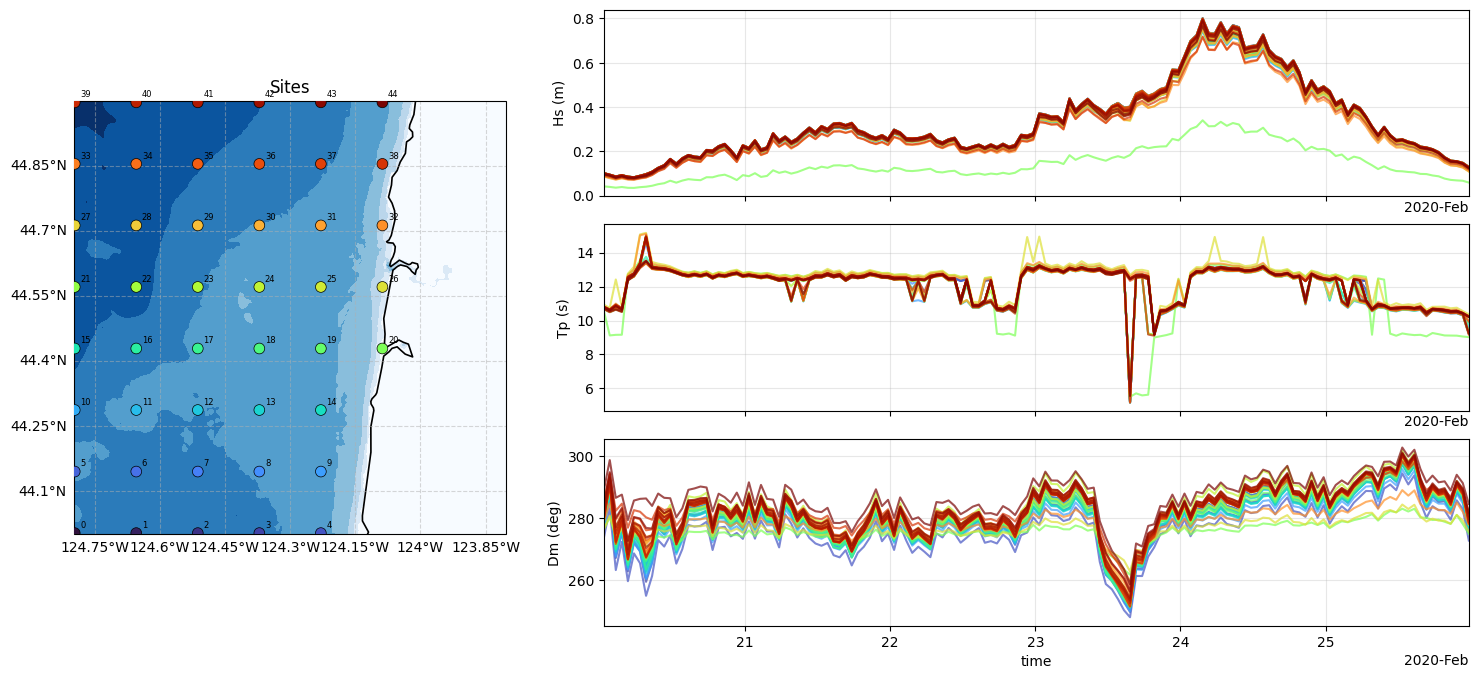

In [8]:
from utils.plotting import plot_site_time_series

fig, axes = plot_site_time_series(
    reconstructed_onshore_spectra=reconstructed_onshore_spectra,
    bathy=bathy,
)